# Brain Tumor MRI — 30-Class Classification
**EfficientNetV2S · 2× GPU MirroredStrategy · Mixed Precision · Anti-Overfitting**

Pipeline:
1. Auto-detect Kaggle dataset path
2. Stratified 70/15/15 split
3. Class-balanced loss + label smoothing (handle 8× imbalance)
4. Phase 1 — head warmup (backbone frozen)
5. Phase 2 — top-100-layer fine-tune with cosine LR decay
6. Save best model as `.keras`
7. Full evaluation: accuracy · macro-F1 · confusion matrix


In [20]:
import kagglehub

print("Đang tải dữ liệu từ Kaggle...")
# Tải toàn bộ thư mục dataset ảnh thô (không qua adapter Pandas)
downloaded_path = kagglehub.dataset_download("fernando2rad/brain-tumor-mri-images-30-classes")

print(f"✓ Dữ liệu đã được tải về thành công tại: {downloaded_path}")

Đang tải dữ liệu từ Kaggle...
✓ Dữ liệu đã được tải về thành công tại: /kaggle/input/datasets/fernando2rad/brain-tumor-mri-images-30-classes


## 1  Install & GPU Check

In [21]:
# ── Install extra packages not pre-installed on Kaggle ──────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "split-folders"])

# Verify GPU
result = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total",
                         "--format=csv,noheader"], capture_output=True, text=True)
print("GPUs detected:")
print(result.stdout.strip() or "  (none)")

GPUs detected:
Tesla T4, 15360 MiB
Tesla T4, 15360 MiB


## 2  Import Libraries

In [22]:
import os, json, random, logging, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import splitfolders

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.applications import EfficientNetV2S

logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.get_logger().setLevel("ERROR")

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"GPUs found : {tf.config.list_physical_devices('GPU')}")

TensorFlow : 2.19.0
NumPy      : 2.4.6
GPUs found : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 3  GPU Strategy & Mixed Precision

In [23]:
# ── Allow GPU memory growth ──────────────────────────────────────────────────
for _gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(_gpu, True)

# ── Distribution strategy ────────────────────────────────────────────────────
_n_gpus = len(tf.config.list_physical_devices("GPU"))
if _n_gpus >= 2:
    strategy = tf.distribute.MirroredStrategy()
    print(f"✓  MirroredStrategy  → {strategy.num_replicas_in_sync} GPUs")
elif _n_gpus == 1:
    strategy = tf.distribute.get_strategy()
    print("✓  Single-GPU strategy")
else:
    strategy = tf.distribute.get_strategy()
    print("⚠  No GPU — running on CPU (slow)")

NUM_REPLICAS = strategy.num_replicas_in_sync

# ── Mixed precision: FP16 compute, FP32 storage (2-3× speedup on T4/A100) ──
tf.keras.mixed_precision.set_global_policy("mixed_float16")
print(f"Precision policy : {tf.keras.mixed_precision.global_policy().name}")

✓  MirroredStrategy  → 2 GPUs
Precision policy : mixed_float16


## 4  Configuration & Paths

In [24]:
from pathlib import Path

# Cấu hình các thư mục làm việc tại Kaggle
WORK_DIR          = Path("/kaggle/working")
SPLIT_DIR         = WORK_DIR / "data_split"
MODEL_DIR         = WORK_DIR / "models"
FIGURE_DIR        = WORK_DIR / "figures"

# Tự động tạo các thư mục đầu ra
for _d in [SPLIT_DIR, MODEL_DIR, FIGURE_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR   = SPLIT_DIR / "val"
TEST_DIR  = SPLIT_DIR / "test"

BEST_MODEL_PATH  = str(MODEL_DIR / "best_model.keras")
FINAL_MODEL_PATH = str(MODEL_DIR / "final_model.keras")

print(f"Split dir  : {SPLIT_DIR}")
print(f"Model dir  : {MODEL_DIR}")

Split dir  : /kaggle/working/data_split
Model dir  : /kaggle/working/models


## 5  Dataset Detection & EDA

In [25]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

# Gán trực tiếp đường dẫn từ thư mục vừa tải về
BRAIN_DATA_DIR = Path(downloaded_path)
print(f"✓ Bộ dữ liệu gốc được thiết lập tại: {BRAIN_DATA_DIR}")

# Kiểm tra xem có đúng cấu trúc các class không
class_dirs = sorted([d for d in BRAIN_DATA_DIR.iterdir() if d.is_dir()])
print(f"Số lượng lớp học (Classes) tìm thấy: {len(class_dirs)}")
print("5 lớp đầu tiên :", [d.name for d in class_dirs[:5]])

✓ Bộ dữ liệu gốc được thiết lập tại: /kaggle/input/datasets/fernando2rad/brain-tumor-mri-images-30-classes
Số lượng lớp học (Classes) tìm thấy: 30
5 lớp đầu tiên : ['Astrocytoma T1', 'Astrocytoma T1C+', 'Astrocytoma T2', 'Ependymoma T1', 'Ependymoma T1C+']


Total images    : 11,300
Largest class   : Meningioma T1C+ (977)
Smallest class  : Hemangiopericytoma T2 (118)
Imbalance ratio : 8.3×  ← handled by class weights


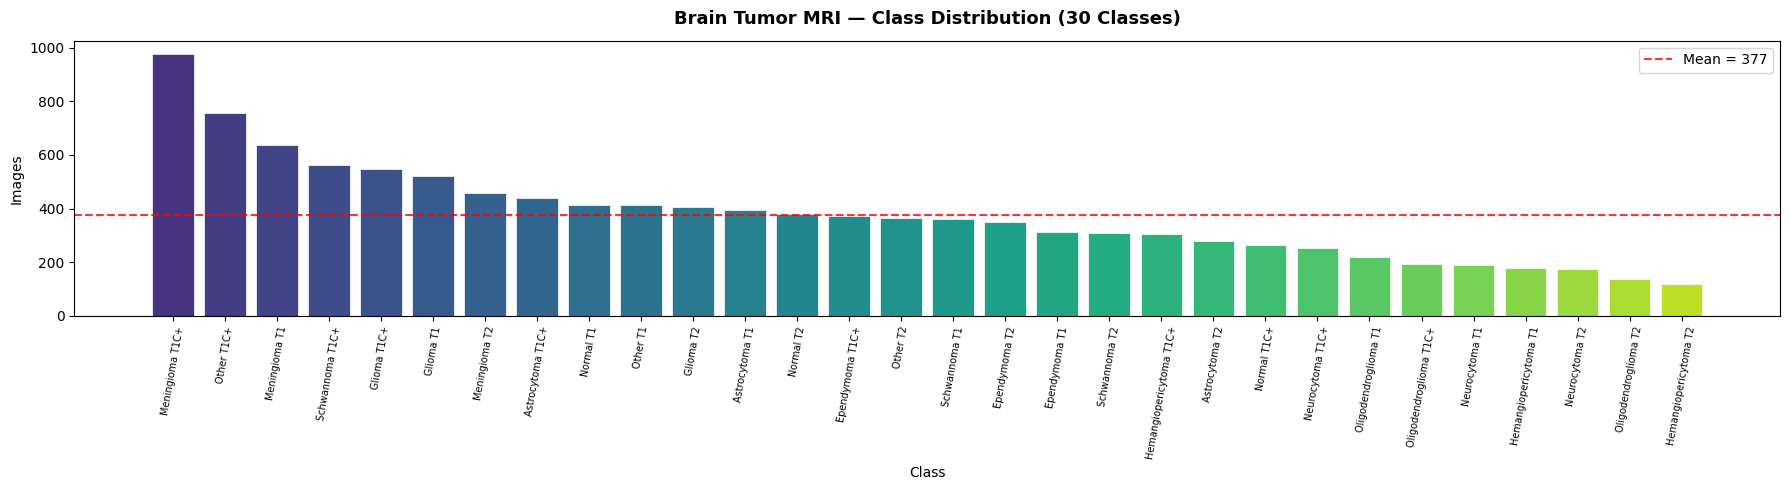

EDA complete.


In [26]:
# ── Count images per class ───────────────────────────────────────────────────
class_info = [
    {"class": d.name,
     "count": sum(1 for f in d.iterdir() if f.suffix.lower() in IMG_EXTS)}
    for d in class_dirs
]
df_dist = (pd.DataFrame(class_info)
             .sort_values("count", ascending=False)
             .reset_index(drop=True))

total_imgs  = df_dist["count"].sum()
imb_ratio   = df_dist["count"].max() / df_dist["count"].min()
print(f"Total images    : {total_imgs:,}")
print(f"Largest class   : {df_dist.iloc[0]['class']} ({df_dist.iloc[0]['count']})")
print(f"Smallest class  : {df_dist.iloc[-1]['class']} ({df_dist.iloc[-1]['count']})")
print(f"Imbalance ratio : {imb_ratio:.1f}×  ← handled by class weights")

# ── Plot distribution ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 5))
colors = plt.cm.viridis(np.linspace(0.15, 0.90, len(df_dist)))
ax.bar(df_dist["class"], df_dist["count"], color=colors, edgecolor="white", lw=0.5)
ax.axhline(df_dist["count"].mean(), color="red", ls="--", alpha=0.8,
           label=f"Mean = {df_dist['count'].mean():.0f}")
ax.set_title("Brain Tumor MRI — Class Distribution (30 Classes)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Class"); ax.set_ylabel("Images")
ax.tick_params(axis="x", rotation=80, labelsize=7)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA complete.")

## 6  Dataset Split  (70 / 15 / 15)

In [27]:
if TRAIN_DIR.exists() and any(TRAIN_DIR.iterdir()):
    print("Split already exists — skipping.")
else:
    print("Splitting dataset  70% train | 15% val | 15% test ...")
    splitfolders.ratio(
        input=str(BRAIN_DATA_DIR),
        output=str(SPLIT_DIR),
        seed=SEED,
        ratio=(0.70, 0.15, 0.15),
        group_prefix=None,
        move=False          # copy — keeps originals intact
    )
    print("Split complete!")

# ── Verify counts ────────────────────────────────────────────────────────────
split_totals = {}
for split_name, split_path in [("TRAIN", TRAIN_DIR), ("VAL", VAL_DIR), ("TEST", TEST_DIR)]:
    n = sum(len(list(cls.glob("*")))
            for cls in split_path.iterdir() if cls.is_dir())
    n_cls = sum(1 for cls in split_path.iterdir() if cls.is_dir())
    split_totals[split_name] = n
    print(f"  {split_name:5s}: {n:,} images across {n_cls} classes")

print(f"  TOTAL: {sum(split_totals.values()):,} images")

Splitting dataset  70% train | 15% val | 15% test ...


Copying files: 11300 files [01:24, 134.41 files/s]


Split complete!
  TRAIN: 7,894 images across 30 classes
  VAL  : 1,681 images across 30 classes
  TEST : 1,725 images across 30 classes
  TOTAL: 11,300 images


## 7  Data Generators

In [28]:
# ── Key design note ──────────────────────────────────────────────────────────
# EfficientNetV2S is built with include_preprocessing=True (see Cell 10).
# That adds an internal Rescaling layer: [0, 255] → [-1, 1].
# Therefore: DO NOT apply rescale or preprocessing_function here.
# Images flow as float32 in [0.0, 255.0]; the model normalises them internally.

train_datagen = ImageDataGenerator(
    # ── Geometric ──────────────────────────────────────
    rotation_range       = 20,
    width_shift_range    = 0.12,
    height_shift_range   = 0.12,
    shear_range          = 0.08,
    zoom_range           = 0.12,
    horizontal_flip      = True,
    vertical_flip        = False,   # brain scans are upright
    # ── Photometric (simulate MRI contrast variation) ──
    brightness_range     = [0.80, 1.20],
    channel_shift_range  = 8.0,
    fill_mode            = "nearest",
    # ── NO rescale ─────────────────────────────────────
)

eval_datagen = ImageDataGenerator()   # no augmentation, no rescale

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, color_mode="rgb",
    batch_size=GLOBAL_BATCH, class_mode="categorical",
    shuffle=True, seed=SEED
)
val_gen = eval_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, color_mode="rgb",
    batch_size=GLOBAL_BATCH, class_mode="categorical", shuffle=False
)
test_gen = eval_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, color_mode="rgb",
    batch_size=GLOBAL_BATCH, class_mode="categorical", shuffle=False
)

NUM_CLASSES  = train_gen.num_classes
CLASS_NAMES  = list(train_gen.class_indices.keys())
CLASS_TO_IDX = train_gen.class_indices
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

print(f"Classes : {NUM_CLASSES}")
print(f"Train   : {len(train_gen)} batches  ({train_gen.n:,} imgs)")
print(f"Val     : {len(val_gen)} batches  ({val_gen.n:,} imgs)")
print(f"Test    : {len(test_gen)} batches  ({test_gen.n:,} imgs)")

Found 7894 images belonging to 30 classes.
Found 1681 images belonging to 30 classes.
Found 1725 images belonging to 30 classes.
Classes : 30
Train   : 124 batches  (7,894 imgs)
Val     : 27 batches  (1,681 imgs)
Test    : 27 batches  (1,725 imgs)


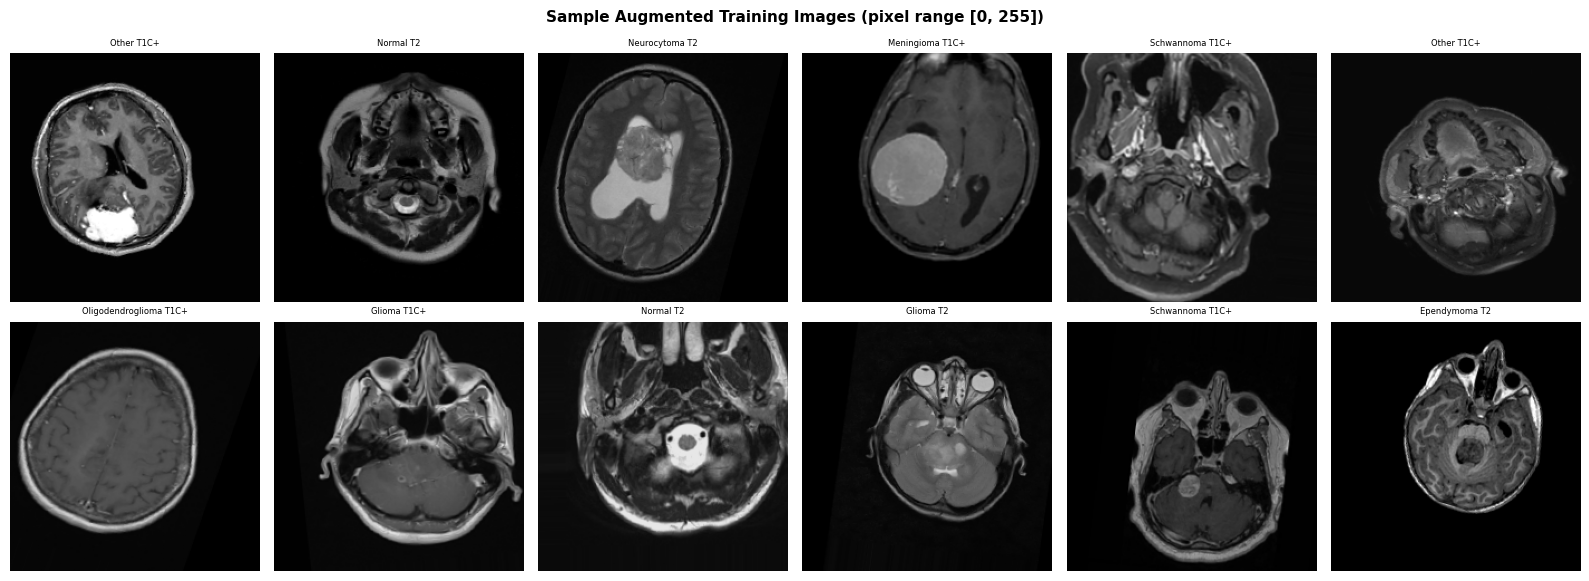

Pixel range in batch: [0.0, 255.0]  (expected ≈ [0, 255])


In [29]:
# ── Visualise augmented sample batch ────────────────────────────────────────
imgs, lbls = next(train_gen)
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle("Sample Augmented Training Images (pixel range [0, 255])",
             fontsize=11, fontweight="bold")
for i, ax in enumerate(axes.flat):
    img_show = np.clip(imgs[i] / 255.0, 0, 1)
    ax.imshow(img_show)
    ax.set_title(CLASS_NAMES[np.argmax(lbls[i])], fontsize=6)
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "augmented_samples.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Pixel range in batch: [{imgs.min():.1f}, {imgs.max():.1f}]  (expected ≈ [0, 255])")

## 8  Class-Imbalance Handling (Weighted Loss + Label Smoothing)

In [30]:
# ── Compute balanced class weights ───────────────────────────────────────────
# sklearn balanced: w_i = n_total / (n_classes * n_i)
# → minority classes get higher weight, majority classes lower weight

train_labels = train_gen.classes   # integer array, one entry per training image

cw_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)
CLASS_WEIGHTS = {i: float(w) for i, w in enumerate(cw_array)}

# Summary table
cw_df = pd.DataFrame([
    {"class": IDX_TO_CLASS[i],
     "train_count": int(np.sum(train_labels == i)),
     "weight": round(float(w), 4)}
    for i, w in CLASS_WEIGHTS.items()
]).sort_values("weight", ascending=False).reset_index(drop=True)

print(f"Weight range: {cw_df['weight'].min():.4f}  →  {cw_df['weight'].max():.4f}")
print(f"Imbalance ratio handled: {cw_df['weight'].max() / cw_df['weight'].min():.2f}×\n")
print("Top 5 up-weighted (minority) classes:")
print(cw_df.head(5).to_string(index=False))
print("\nTop 5 down-weighted (majority) classes:")
print(cw_df.tail(5).to_string(index=False))

Weight range: 0.3853  →  3.2089
Imbalance ratio handled: 8.33×

Top 5 up-weighted (minority) classes:
                class  train_count  weight
Hemangiopericytoma T2           82  3.2089
 Oligodendroglioma T2           95  2.7698
       Neurocytoma T2          121  2.1747
Hemangiopericytoma T1          124  2.1220
       Neurocytoma T1          133  1.9784

Top 5 down-weighted (majority) classes:
          class  train_count  weight
    Glioma T1C+          384  0.6852
Schwannoma T1C+          394  0.6679
  Meningioma T1          445  0.5913
     Other T1C+          529  0.4974
Meningioma T1C+          683  0.3853


## 9  Model Architecture  (EfficientNetV2S)

In [31]:
def build_model(input_shape: tuple, num_classes: int):
    """
    EfficientNetV2S backbone + custom classification head.

    Architecture:
      EfficientNetV2S (frozen in Phase 1)
        → GlobalAveragePooling2D
        → BatchNormalization
        → Dense(512, swish, L2=1e-4) + Dropout(0.40)
        → Dense(256, swish, L2=1e-4) + Dropout(0.30)
        → Dense(num_classes, softmax, dtype=float32)

    Anti-overfitting:
      • Dropout 0.40 + 0.30
      • L2 regularisation on Dense layers
      • BatchNorm after GAP
      • Label smoothing in loss (Cell 10)
      • Class weights passed to fit() (Cell 10)
      • Data augmentation (Cell 7)
      • EarlyStopping (Cells 11 & 12)

    Note on preprocessing:
      include_preprocessing=True adds an internal Rescaling layer.
      Model expects raw [0, 255] input; normalises to [-1, 1] internally.
    """
    backbone = EfficientNetV2S(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape,
        include_preprocessing=True   # [0,255] → [-1,1] inside model
    )
    backbone.trainable = False  # frozen for Phase 1 warmup

    inputs = tf.keras.Input(shape=input_shape, name="image_input")

    # Feature extraction
    x = backbone(inputs, training=False)   # (B, 7, 7, 1280) @ 224×224

    # ── Classification head ───────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="bn_head")(x)

    x = layers.Dense(
        512, activation="swish",
        kernel_regularizer=regularizers.l2(1e-4),
        name="dense_512"
    )(x)
    x = layers.Dropout(0.40, name="drop_1")(x)

    x = layers.Dense(
        256, activation="swish",
        kernel_regularizer=regularizers.l2(1e-4),
        name="dense_256"
    )(x)
    x = layers.Dropout(0.30, name="drop_2")(x)

    # Force float32 for the output — critical for mixed_float16 stability
    outputs = layers.Dense(
        num_classes, activation="softmax",
        dtype="float32",
        name="class_output"
    )(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs,
                           name="BrainTumor_EfficientNetV2S")
    return model, backbone


# ── Build inside strategy scope for multi-GPU ────────────────────────────────
with strategy.scope():
    model, backbone = build_model(INPUT_SHAPE, NUM_CLASSES)

model.summary(line_length=100, expand_nested=False)

total_p     = model.count_params()
trainable_p = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f"\nTotal params    : {total_p:,}")
print(f"Trainable params: {trainable_p:,}  (heads only — backbone frozen in Phase 1)")

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "BrainTumor_EfficientNetV2S"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)                   │ (None, 224, 224, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ efficientnetv2-s (Functional)              │ (None, 7, 7, 1280)              │        20,331,360 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ gap (GlobalAveragePooling2D)               │ (None, 1280)                    │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ bn_head (BatchNormalization)               │ (None, 1280)                    │             5,120 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_512 (Dense)                          │ (None, 512)                     │           655,872 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ drop_1 (Dropout)                           │ (None, 512)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_256 (Dense)                          │ (None, 256)                     │           131,328 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ drop_2 (Dropout)                           │ (None, 256)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ class_output (Dense)                       │ (None, 30)                      │             7,710 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 21,131,390 (80.61 MB)

 Trainable params: 797,470 (3.04 MB)

 Non-trainable params: 20,333,920 (77.57 MB)


Total params    : 21,131,390
Trainable params: 797,470  (heads only — backbone frozen in Phase 1)


## 10  Phase 1 — Head Warmup  (backbone frozen)

In [32]:
# ── Loss: CategoricalCrossentropy + label smoothing ──────────────────────────
# label_smoothing=0.10 → soft targets reduce overconfidence and improve calibration
LOSS_FN = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.10)

METRICS = [
    "accuracy",
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
    tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
]

with strategy.scope():
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR_PHASE1),
        loss=LOSS_FN,
        metrics=METRICS
    )
print(f"Phase 1 compiled  lr={LR_PHASE1}  backbone=FROZEN")

callbacks_p1 = [
    ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_accuracy", save_best_only=True,
        mode="max", verbose=1
    ),
    EarlyStopping(
        monitor="val_loss", patience=7,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4,
        min_lr=1e-6, verbose=1
    ),
]

print("\n" + "="*58)
print(f"  PHASE 1 — HEAD WARMUP")
print(f"  Epochs  : {EPOCHS_PHASE1}   Batch : {GLOBAL_BATCH}")
print(f"  LR      : {LR_PHASE1}   Backbone : FROZEN")
print("="*58)

history_p1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_p1,
    class_weight=CLASS_WEIGHTS,   # handle class imbalance
    verbose=1
)

best_val_p1 = max(history_p1.history["val_accuracy"])
print(f"\nPhase 1 done  |  Best val accuracy: {best_val_p1*100:.2f}%")

Phase 1 compiled  lr=0.001  backbone=FROZEN

  PHASE 1 — HEAD WARMUP
  Epochs  : 15   Batch : 64
  LR      : 0.001   Backbone : FROZEN
Epoch 1/15


I0000 00:00:1780618897.884221     134 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780618898.471218     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 834ms/step - accuracy: 0.1540 - loss: 3.2881 - precision: 0.3462 - recall: 0.0288 - top3_acc: 0.3434
Epoch 1: val_accuracy improved from None to 0.44021, saving model to /kaggle/working/models/best_model.keras

Epoch 1: finished saving model to /kaggle/working/models/best_model.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.2363 - loss: 2.9144 - precision: 0.5264 - recall: 0.0606 - top3_acc: 0.4598 - val_accuracy: 0.4402 - val_loss: 2.5720 - val_precision: 1.0000 - val_recall: 0.0077 - val_top3_acc: 0.6996 - learning_rate: 0.0010
Epoch 2/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - accuracy: 0.3713 - loss: 2.4379 - precision: 0.6643 - recall: 0.1529 - top3_acc: 0.6277
Epoch 2: val_accuracy improved from 0.44021 to 0.52528, saving model to /kaggle/working/models/best_model.keras

Epoch 2: finished saving model to /kaggle/working/models/best_model.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 111s 890ms/step - accuracy: 0.3856 - loss: 2.3821 - preci

## 11  Phase 2 — Fine-tuning  (unfreeze top 100 backbone layers)

In [33]:
# ── Unfreeze top UNFREEZE_LAYERS layers of EfficientNetV2S ──────────────────
backbone.trainable = True
fine_tune_at = len(backbone.layers) - UNFREEZE_LAYERS

for layer in backbone.layers[:fine_tune_at]:
    layer.trainable = False

# CRITICAL: keep BatchNorm in inference mode during fine-tune
# Reason: small batches can corrupt running statistics → instability
for layer in backbone.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_bb = sum(1 for l in backbone.layers if l.trainable)
print(f"Unfrozen backbone layers: {trainable_bb} / {len(backbone.layers)}")

# ── Cosine decay with warm restarts  ────────────────────────────────────────
# Smooth LR annealing prevents sharp overfitting jumps during fine-tune
total_steps_p2 = len(train_gen) * EPOCHS_PHASE2
lr_schedule_p2 = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate = LR_PHASE2_INIT,  # 2e-4
    first_decay_steps     = total_steps_p2 // 3,
    t_mul=1.5, m_mul=0.90,
    alpha=LR_PHASE2_MIN   # floor = 1e-6
)

with strategy.scope():
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule_p2),
        loss=LOSS_FN,
        metrics=METRICS
    )
print(f"Phase 2 compiled  lr=2e-4→1e-6 (cosine)")

callbacks_p2 = [
    ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_accuracy", save_best_only=True,
        mode="max", verbose=1
    ),
    EarlyStopping(
        monitor="val_loss", patience=12,
        restore_best_weights=True, verbose=1
    ),
]

print("\n" + "="*58)
print(f"  PHASE 2 — FINE-TUNING")
print(f"  Epochs  : {EPOCHS_PHASE2} (max)   Batch : {GLOBAL_BATCH}")
print(f"  LR      : cosine 2e-4 → 1e-6   Backbone : TOP {UNFREEZE_LAYERS} UNFROZEN")
print("="*58)

history_p2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_p2,
    class_weight=CLASS_WEIGHTS,
    verbose=1
)

# Save final model (last epoch weights)
model.save(FINAL_MODEL_PATH)
print(f"\nFinal model saved  : {FINAL_MODEL_PATH}")
print(f"Best model saved   : {BEST_MODEL_PATH}")

best_val_p2 = max(history_p2.history["val_accuracy"])
print(f"Phase 2 best val accuracy: {best_val_p2*100:.2f}%")

Unfrozen backbone layers: 80 / 513
Phase 2 compiled  lr=2e-4→1e-6 (cosine)

  PHASE 2 — FINE-TUNING
  Epochs  : 60 (max)   Batch : 64
  LR      : cosine 2e-4 → 1e-6   Backbone : TOP 100 UNFROZEN
Epoch 1/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.7142 - loss: 1.5768 - precision: 0.8819 - recall: 0.5350 - top3_acc: 0.8981
Epoch 1: val_accuracy improved from None to 0.74420, saving model to /kaggle/working/models/best_model.keras

Epoch 1: finished saving model to /kaggle/working/models/best_model.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 158s 969ms/step - accuracy: 0.7236 - loss: 1.5575 - precision: 0.8827 - recall: 0.5445 - top3_acc: 0.9066 - val_accuracy: 0.7442 - val_loss: 1.6022 - val_precision: 0.9519 - val_recall: 0.4830 - val_top3_acc: 0.9030
Epoch 2/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 836ms/step - accuracy: 0.7712 - loss: 1.4521 - precision: 0.9146 - recall: 0.5991 - top3_acc: 0.9299
Epoch 2: val_accuracy improved from 0.74420 to 0.80607, saving model to /kaggle/working/

## 12  Training History Curves

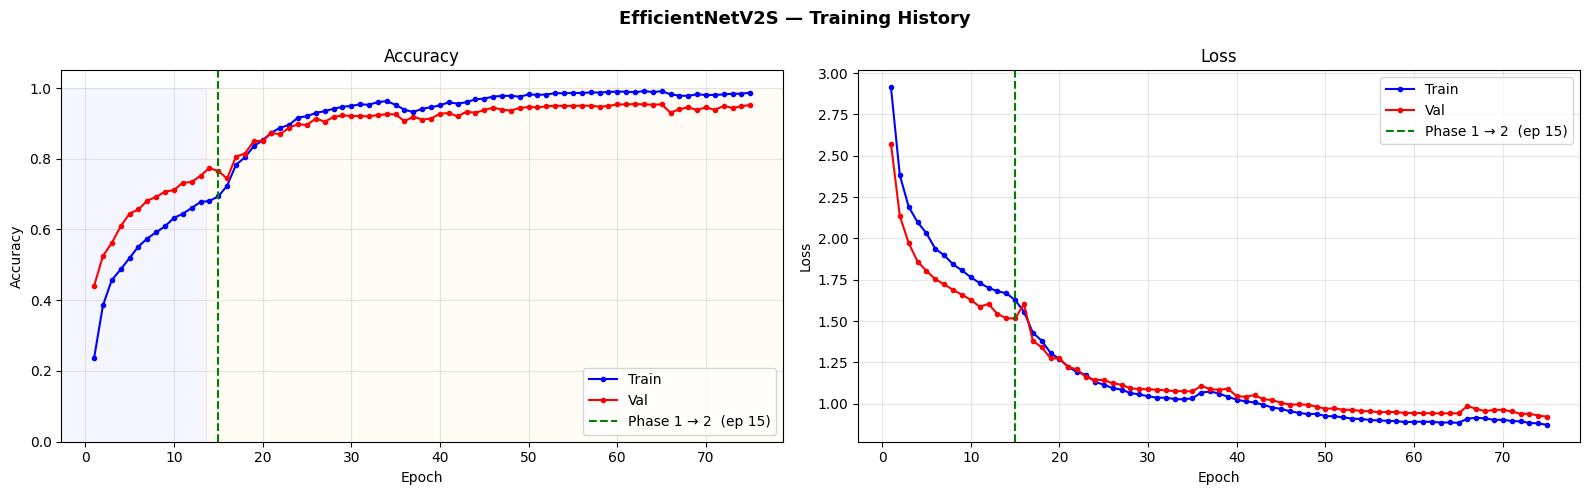


Total epochs trained  : 75
Best val acc epoch    : 62  (95.48%)
Train/Val gap (final) : +3.48%  ✓ OK


In [34]:
def plot_history(h1, h2, phase1_len, save_path):
    all_acc      = h1.history["accuracy"]      + h2.history["accuracy"]
    all_val_acc  = h1.history["val_accuracy"]  + h2.history["val_accuracy"]
    all_loss     = h1.history["loss"]          + h2.history["loss"]
    all_val_loss = h1.history["val_loss"]      + h2.history["val_loss"]
    ep = range(1, len(all_acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("EfficientNetV2S — Training History",
                 fontsize=13, fontweight="bold")

    # ── Accuracy ─────────────────────────────────────────────────────────
    ax1.plot(ep, all_acc,     "b-o", ms=3, lw=1.5, label="Train")
    ax1.plot(ep, all_val_acc, "r-o", ms=3, lw=1.5, label="Val")
    ax1.axvline(phase1_len, color="green", ls="--", lw=1.5,
                label=f"Phase 1 → 2  (ep {phase1_len})")
    ax1.axhspan(0, 1, xmin=0, xmax=phase1_len/len(ep),
                alpha=0.04, color="blue")
    ax1.axhspan(0, 1, xmin=phase1_len/len(ep), xmax=1,
                alpha=0.04, color="orange")
    ax1.set_title("Accuracy")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1.05)

    # ── Loss ─────────────────────────────────────────────────────────────
    ax2.plot(ep, all_loss,     "b-o", ms=3, lw=1.5, label="Train")
    ax2.plot(ep, all_val_loss, "r-o", ms=3, lw=1.5, label="Val")
    ax2.axvline(phase1_len, color="green", ls="--", lw=1.5,
                label=f"Phase 1 → 2  (ep {phase1_len})")
    ax2.set_title("Loss")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


phase1_len = len(history_p1.history["accuracy"])
plot_history(history_p1, history_p2, phase1_len,
             FIGURE_DIR / "training_history.png")

# ── Overfitting check ────────────────────────────────────────────────────────
all_acc     = history_p1.history["accuracy"]     + history_p2.history["accuracy"]
all_val_acc = history_p1.history["val_accuracy"] + history_p2.history["val_accuracy"]
final_gap   = all_acc[-1] - all_val_acc[-1]
best_ep     = int(np.argmax(all_val_acc)) + 1

print(f"\nTotal epochs trained  : {len(all_acc)}")
print(f"Best val acc epoch    : {best_ep}  ({max(all_val_acc)*100:.2f}%)")
print(f"Train/Val gap (final) : {final_gap*100:+.2f}%",
      " ✓ OK" if abs(final_gap) < 0.10 else " ⚠ check for overfitting")

## 13  Load Best Model & Test-Set Evaluation

In [35]:
print(f"Loading best checkpoint: {BEST_MODEL_PATH}")
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

# ── evaluate() → gives loss + metrics ────────────────────────────────────────
print("\n--- evaluate() on test set ---")
test_results = best_model.evaluate(test_gen, verbose=1)
for name, val in zip(best_model.metrics_names, test_results):
    print(f"  {name:28s}: {val:.4f}")

Loading best checkpoint: /kaggle/working/models/best_model.keras

--- evaluate() on test set ---
27/27 ━━━━━━━━━━━━━━━━━━━━ 29s 468ms/step - accuracy: 0.9525 - loss: 0.9384 - precision: 0.9807 - recall: 0.9142 - top3_acc: 0.9930
  loss                        : 0.9384
  compile_metrics             : 0.9525


## 14  Predictions & Classification Report

In [36]:
# ── Run predict over entire test set ────────────────────────────────────────
print("Predicting test set...")
test_gen.reset()   # important: reset to index 0 before predict
y_pred_probs = best_model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_gen.classes

# Trim to valid length (partial last batch)
n      = min(len(y_pred), len(y_true))
y_pred = y_pred[:n]
y_true = y_true[:n]

# ── Summary metrics ──────────────────────────────────────────────────────────
acc        = accuracy_score(y_true, y_pred)
prec_macro = precision_score(y_true, y_pred, average="macro",    zero_division=0)
rec_macro  = recall_score(y_true,    y_pred, average="macro",    zero_division=0)
f1_macro   = f1_score(y_true,        y_pred, average="macro",    zero_division=0)
f1_weight  = f1_score(y_true,        y_pred, average="weighted", zero_division=0)

print("\n" + "="*60)
print("  TEST SET SUMMARY")
print("="*60)
print(f"  Accuracy            : {acc*100:.2f}%")
print(f"  Macro  Precision    : {prec_macro:.4f}")
print(f"  Macro  Recall       : {rec_macro:.4f}")
print(f"  Macro  F1-score     : {f1_macro:.4f}")
print(f"  Weighted F1-score   : {f1_weight:.4f}")
print("="*60)

# ── Per-class report ─────────────────────────────────────────────────────────
print("\n--- Per-Class Classification Report ---\n")
print(classification_report(y_true, y_pred,
                             target_names=CLASS_NAMES,
                             zero_division=0))

Predicting test set...
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 385ms/step

  TEST SET SUMMARY
  Accuracy            : 95.25%
  Macro  Precision    : 0.9550
  Macro  Recall       : 0.9468
  Macro  F1-score     : 0.9494
  Weighted F1-score   : 0.9523

--- Per-Class Classification Report ---

                         precision    recall  f1-score   support

         Astrocytoma T1       0.95      0.95      0.95        60
       Astrocytoma T1C+       0.96      0.97      0.96        67
         Astrocytoma T2       0.97      0.74      0.84        43
          Ependymoma T1       0.80      0.90      0.84        48
        Ependymoma T1C+       1.00      1.00      1.00        57
          Ependymoma T2       0.88      0.85      0.87        54
              Glioma T1       0.99      0.97      0.98        79
            Glioma T1C+       0.95      0.95      0.95        83
              Glioma T2       0.95      0.95      0.95        62
  Hemangiopericytoma T1       0.96      0.96      0.96        28
He

## 15  Confusion Matrix

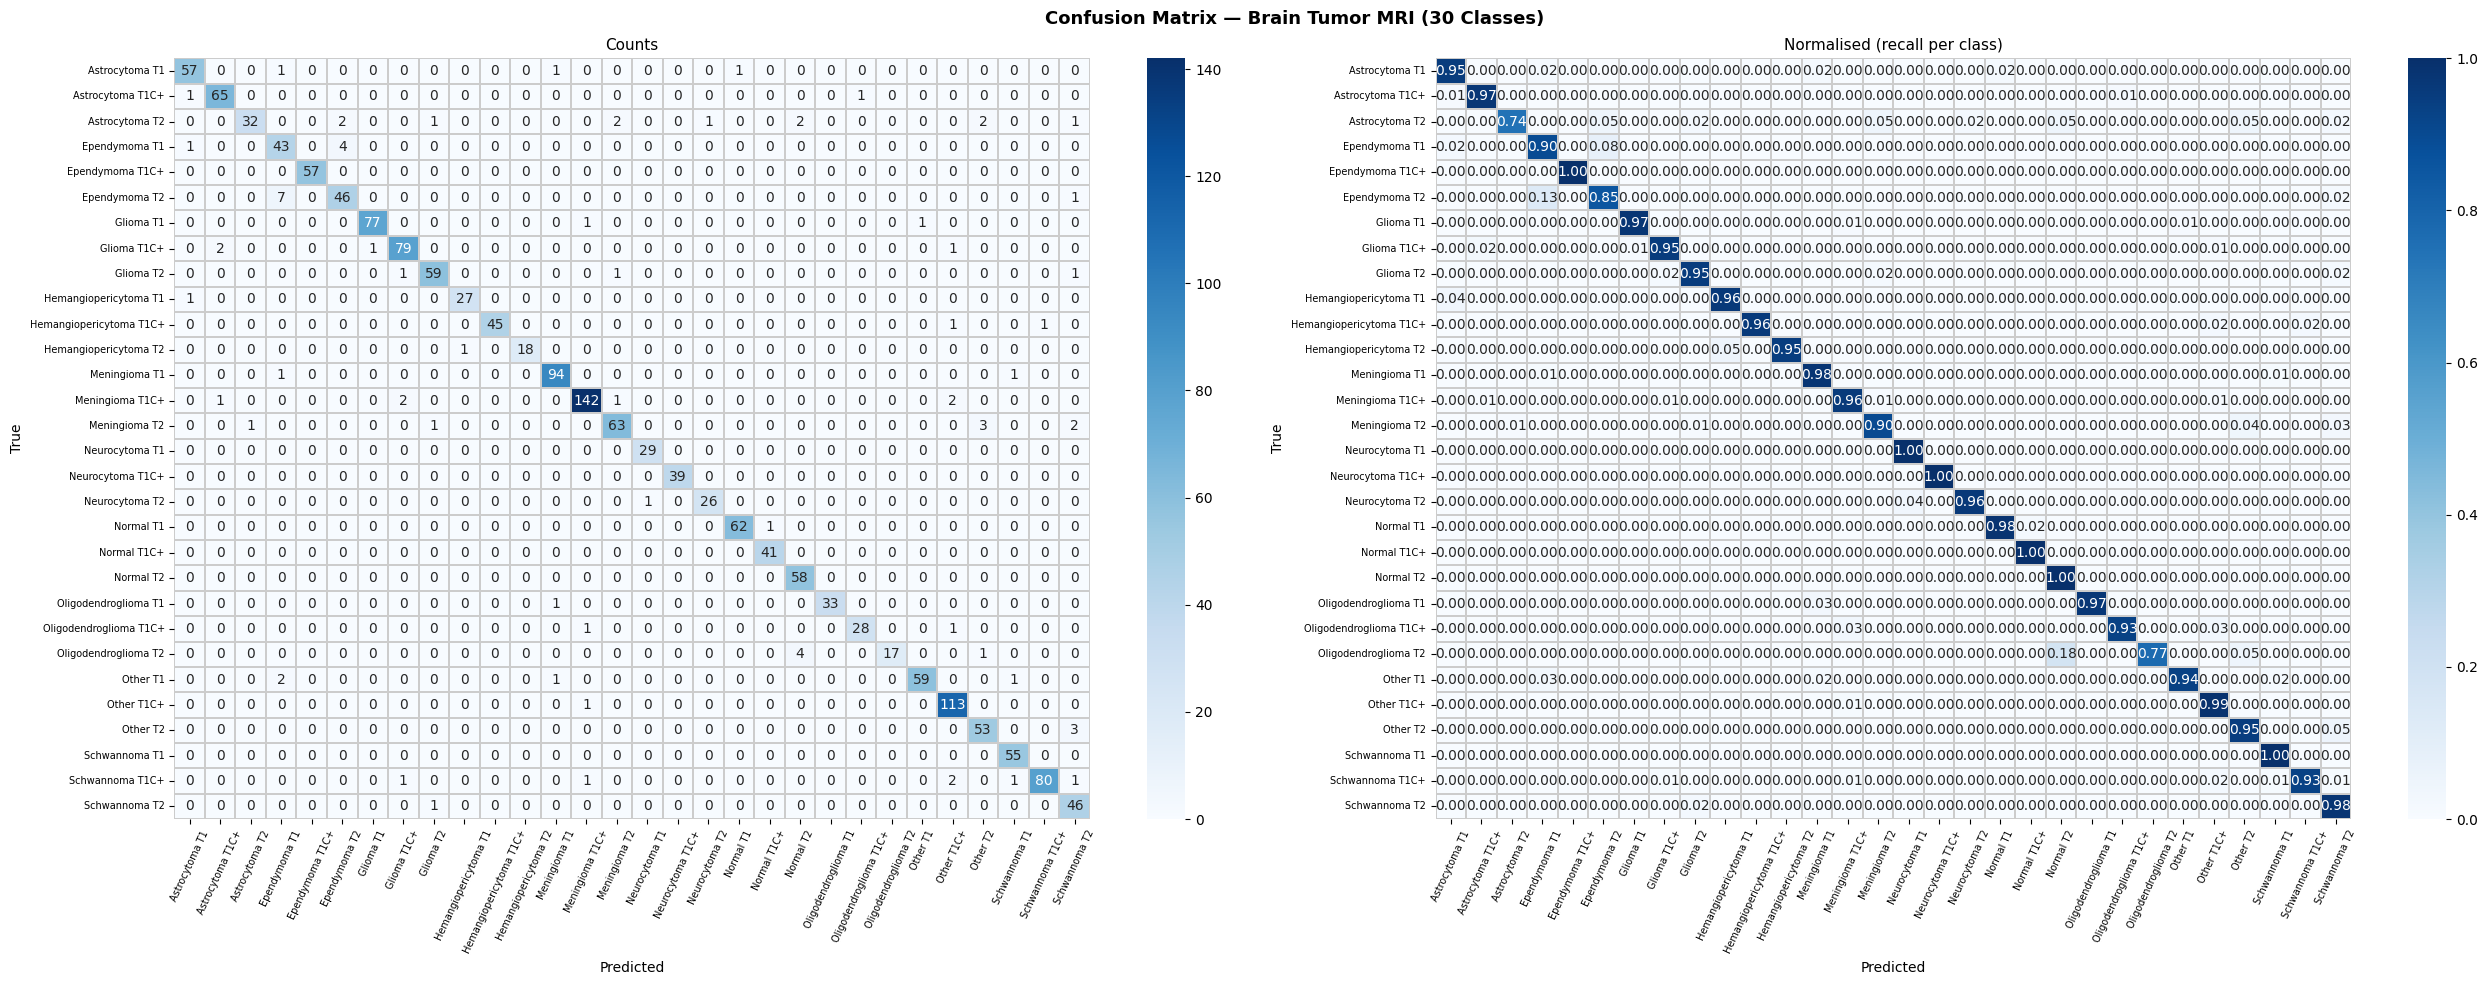


Bottom 5 classes (most confused — need more data or augmentation):
               class  per_class_recall
      Astrocytoma T2          0.744186
Oligodendroglioma T2          0.772727
       Ependymoma T2          0.851852
       Ependymoma T1          0.895833
       Meningioma T2          0.900000

Top 5 classes (best recalled):
           class  per_class_recall
 Ependymoma T1C+               1.0
Neurocytoma T1C+               1.0
     Normal T1C+               1.0
       Normal T2               1.0
   Schwannoma T1               1.0

Mean per-class recall: 0.9468


In [37]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(26, 10))
fig.suptitle("Confusion Matrix — Brain Tumor MRI (30 Classes)",
             fontsize=13, fontweight="bold")

kw = dict(xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
          linewidths=0.3, linecolor="#cccccc")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0], **kw)
axes[0].set_title("Counts", fontsize=11)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=65, labelsize=7)
axes[0].tick_params(axis="y", rotation=0,  labelsize=7)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            vmin=0, vmax=1, ax=axes[1], **kw)
axes[1].set_title("Normalised (recall per class)", fontsize=11)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].tick_params(axis="x", rotation=65, labelsize=7)
axes[1].tick_params(axis="y", rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Per-class performance summary ────────────────────────────────────────────
diag = cm_norm.diagonal()
cls_perf = pd.Series(diag, index=CLASS_NAMES).rename("recall").reset_index()
cls_perf.columns = ["class", "per_class_recall"]
cls_perf = cls_perf.sort_values("per_class_recall")

print("\nBottom 5 classes (most confused — need more data or augmentation):")
print(cls_perf.head(5).to_string(index=False))
print("\nTop 5 classes (best recalled):")
print(cls_perf.tail(5).to_string(index=False))
print(f"\nMean per-class recall: {diag.mean():.4f}")

## 16  Per-Class F1 Bar Chart

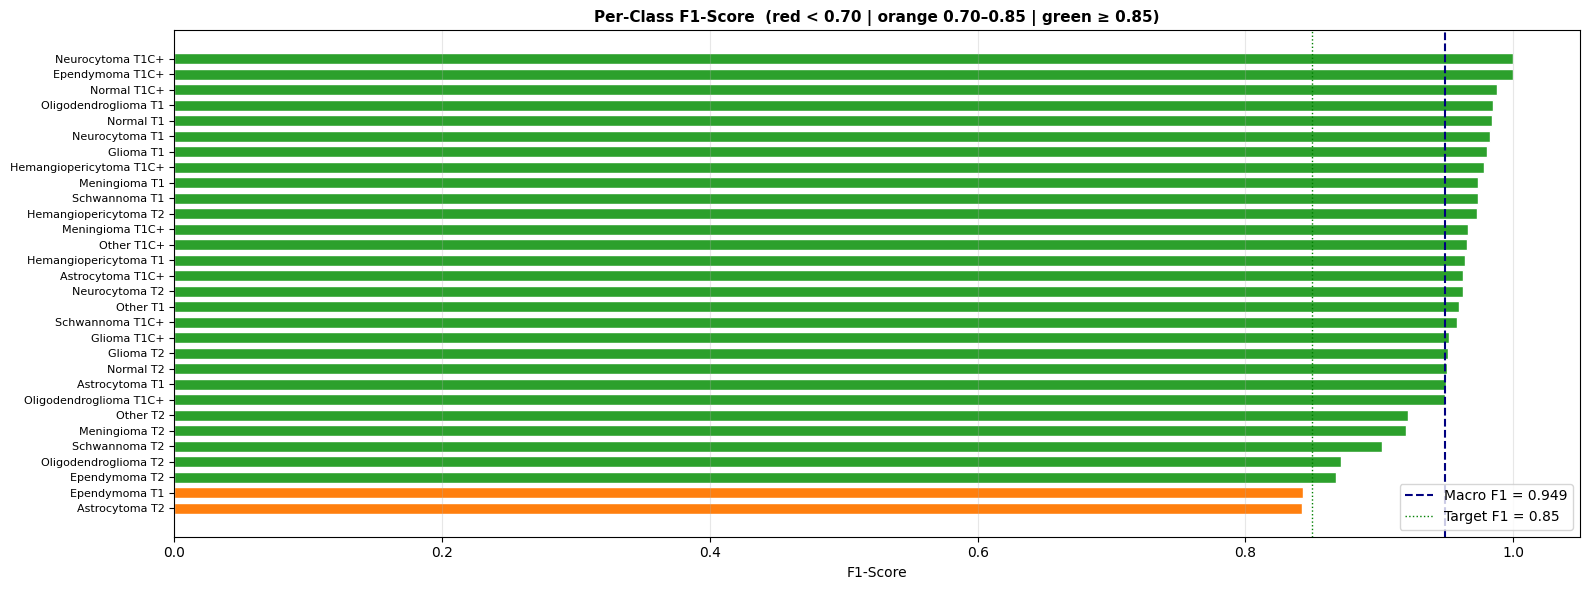

Classes with F1 < 0.70 : 0
Classes with F1 ≥ 0.85 : 28 / 30


In [38]:
from sklearn.metrics import f1_score as _f1

per_class_f1 = _f1(y_true, y_pred, average=None, zero_division=0)
f1_df = pd.DataFrame({"class": CLASS_NAMES, "f1": per_class_f1})
f1_df = f1_df.sort_values("f1")

fig, ax = plt.subplots(figsize=(16, 6))
colors2 = ["#d62728" if v < 0.70 else ("#ff7f0e" if v < 0.85 else "#2ca02c")
           for v in f1_df["f1"]]
ax.barh(f1_df["class"], f1_df["f1"], color=colors2, edgecolor="white", height=0.7)
ax.axvline(f1_macro, color="navy", ls="--", lw=1.5,
           label=f"Macro F1 = {f1_macro:.3f}")
ax.axvline(0.85, color="green", ls=":", lw=1,
           label="Target F1 = 0.85")
ax.set_title("Per-Class F1-Score  (red < 0.70 | orange 0.70–0.85 | green ≥ 0.85)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("F1-Score"); ax.set_xlim(0, 1.05)
ax.tick_params(axis="y", labelsize=8)
ax.legend(); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Classes with F1 < 0.70 : {(per_class_f1 < 0.70).sum()}")
print(f"Classes with F1 ≥ 0.85 : {(per_class_f1 >= 0.85).sum()} / {NUM_CLASSES}")

## 17  Sample Predictions

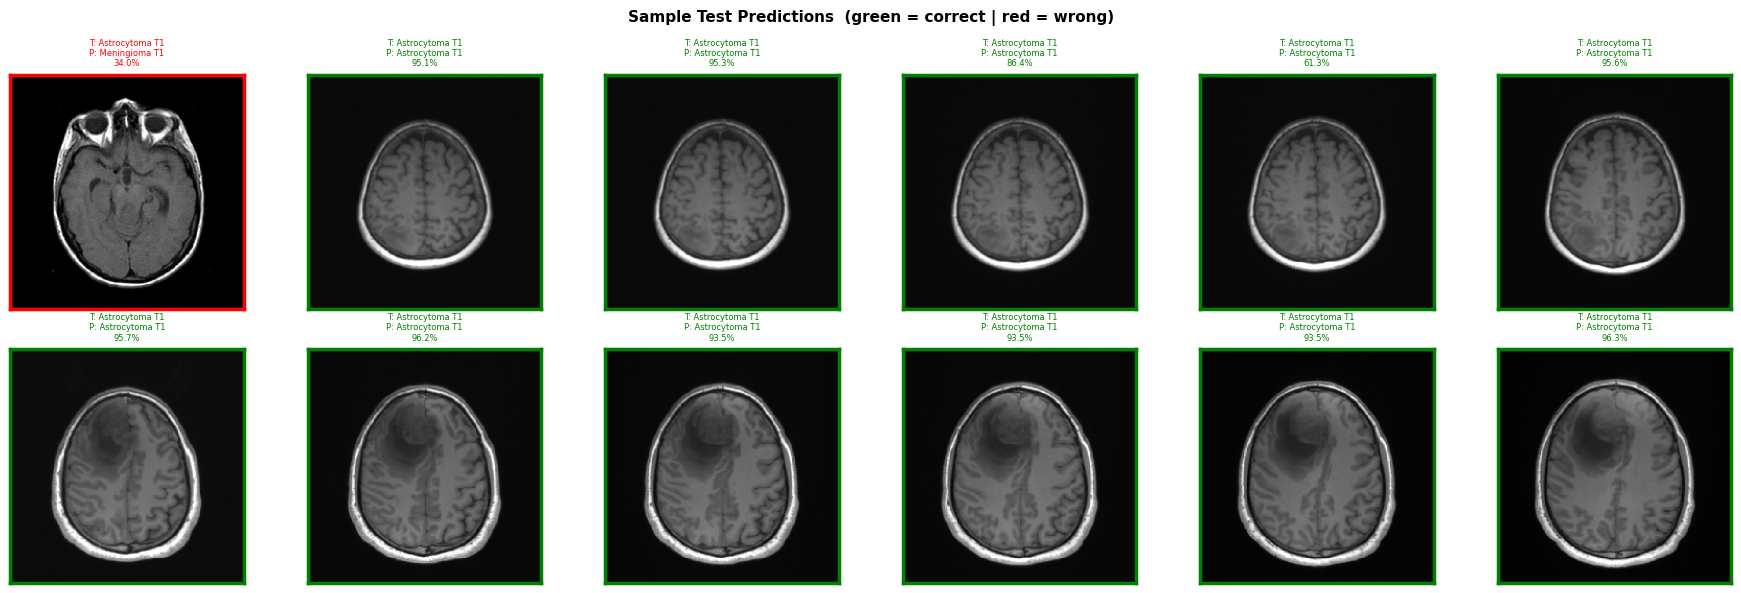

In [39]:
# ── Show 12 test samples: correct (green) / wrong (red) ─────────────────────
test_gen.reset()
imgs_batch, lbls_batch = next(test_gen)
preds_batch = best_model.predict(imgs_batch, verbose=0)

n_show = min(12, len(imgs_batch))
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle("Sample Test Predictions  (green = correct | red = wrong)",
             fontsize=11, fontweight="bold")

for i, ax in enumerate(axes.flat[:n_show]):
    img_disp = np.clip(imgs_batch[i] / 255.0, 0, 1)
    true_cls = CLASS_NAMES[np.argmax(lbls_batch[i])]
    pred_cls = CLASS_NAMES[np.argmax(preds_batch[i])]
    conf     = float(preds_batch[i].max())
    correct  = (true_cls == pred_cls)

    ax.imshow(img_disp)
    ax.set_title(
        f"T: {true_cls}\nP: {pred_cls}\n{conf*100:.1f}%",
        fontsize=6,
        color="green" if correct else "red"
    )
    # Coloured border
    for spine in ax.spines.values():
        spine.set_edgecolor("green" if correct else "red")
        spine.set_linewidth(2.5)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

## 18  Export Artifacts & Final Summary

In [40]:
# ── Save class-name mapping ───────────────────────────────────────────────────
class_map = {str(idx): name for idx, name in IDX_TO_CLASS.items()}
with open(MODEL_DIR / "class_names.json", "w") as fh:
    json.dump(class_map, fh, indent=2)

# ── Save full metrics to JSON ─────────────────────────────────────────────────
metrics_out = {
    "architecture"     : "EfficientNetV2S + Custom Head",
    "input_size"       : list(IMG_SIZE),
    "num_classes"      : NUM_CLASSES,
    "num_gpus"         : int(NUM_REPLICAS),
    "global_batch"     : int(GLOBAL_BATCH),
    "phase1_epochs"    : int(len(history_p1.history["accuracy"])),
    "phase2_epochs"    : int(len(history_p2.history["accuracy"])),
    "total_epochs"     : int(len(history_p1.history["accuracy"]) +
                             len(history_p2.history["accuracy"])),
    "best_val_accuracy": float(max(history_p1.history["val_accuracy"] +
                                   history_p2.history["val_accuracy"])),
    "test_accuracy"    : float(acc),
    "precision_macro"  : float(prec_macro),
    "recall_macro"     : float(rec_macro),
    "f1_macro"         : float(f1_macro),
    "f1_weighted"      : float(f1_weight),
}
with open(MODEL_DIR / "metrics.json", "w") as fh:
    json.dump(metrics_out, fh, indent=2)

# ── List output files ─────────────────────────────────────────────────────────
print("Output files:")
for f in sorted(MODEL_DIR.rglob("*")):
    if f.is_file():
        print(f"  {f}  ({f.stat().st_size // 1024:,} KB)")

# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("  TRAINING COMPLETE — FINAL SUMMARY")
print("="*65)
print(f"  Architecture      : EfficientNetV2S + Custom Head")
print(f"  Input size        : {IMG_SIZE}")
print(f"  Classes           : {NUM_CLASSES}")
print(f"  GPUs used         : {NUM_REPLICAS}")
print(f"  Global batch size : {GLOBAL_BATCH}")
print(f"  Phase 1 epochs    : {metrics_out['phase1_epochs']}")
print(f"  Phase 2 epochs    : {metrics_out['phase2_epochs']}")
print(f"  Total epochs      : {metrics_out['total_epochs']}")
print(f"  Best Val Accuracy : {metrics_out['best_val_accuracy']*100:.2f}%")
print(f"  Test Accuracy     : {metrics_out['test_accuracy']*100:.2f}%")
print(f"  Macro F1-score    : {metrics_out['f1_macro']:.4f}")
print(f"  Weighted F1-score : {metrics_out['f1_weighted']:.4f}")
print(f"  Best model        : {BEST_MODEL_PATH}")
print(f"  Class map         : {MODEL_DIR / 'class_names.json'}")
print("="*65)

Output files:
  /kaggle/working/models/best_model.keras  (204,819 KB)
  /kaggle/working/models/class_names.json  (0 KB)
  /kaggle/working/models/final_model.keras  (204,819 KB)
  /kaggle/working/models/metrics.json  (0 KB)

  TRAINING COMPLETE — FINAL SUMMARY
  Architecture      : EfficientNetV2S + Custom Head
  Input size        : (224, 224)
  Classes           : 30
  GPUs used         : 2
  Global batch size : 64
  Phase 1 epochs    : 15
  Phase 2 epochs    : 60
  Total epochs      : 75
  Best Val Accuracy : 95.48%
  Test Accuracy     : 95.25%
  Macro F1-score    : 0.9494
  Weighted F1-score : 0.9523
  Best model        : /kaggle/working/models/best_model.keras
  Class map         : /kaggle/working/models/class_names.json
